In [4]:
import xgboost
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))
import pandas as pd
from datetime import datetime
from src import experiment_tracking
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import clone
from time import perf_counter
import json
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve
)

In [ ]:
nome_experimento = (
    "catboost_native_cat_"
    "depth6_lr005_"
    "l2_3_threshold_050"
)

observacao = (
    "Terceira execução do CatBoost. "
    "Modelo oficial que será congelado"
)

In [ ]:
threshold_inicial_value = 0.50

iterations_value = 1500
learning_rate_value = 0.05

depth_value = 6

l2_leaf_reg_value = 3.0
random_strength_value = 1.0

loss_function_value = "Logloss"
eval_metric_value = "PRAUC:type=Classic"

early_stopping_rounds_value = 50

has_time_value = True
class_weights_value = None

random_seed_value = 42
verbose_value = 50

In [39]:
df = pd.read_csv("../raw/fraudTrain.csv", parse_dates = ["trans_date_trans_time", "dob"], dtype = {"cc_num": "string", "trans_num": "string", "zip": "string"})

In [40]:
features_basicas_v1 = [
    "amt_log",
    "city_pop_log",
    "idade",
    "distancia_km",
    "hora_sin",
    "hora_cos",
    "dia_semana_sin",
    "dia_semana_cos",
    "fim_de_semana",
    "category",
    "gender",
    "state"
]

In [41]:
colunas_numericas = [
    "amt_log",
    "city_pop_log",
    "idade",
    "distancia_km",
    "hora_sin",
    "hora_cos",
    "dia_semana_sin",
    "dia_semana_cos",
    "fim_de_semana"
]

colunas_categoricas = [
    "category",
    "gender",
    "state"
]

In [42]:

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

def avaliar_modelo(
    y_real,
    scores,
    threshold
) -> pd.DataFrame:
    """
    Avalia um modelo de classificação binária a partir dos scores
    atribuídos à classe positiva.

    Parâmetros
    ----------
    y_real:
        Classes reais. Espera-se 0 para transação legítima e
        1 para transação fraudulenta.

    scores:
        Probabilidade ou score atribuído à classe de fraude.

        Exemplo:
        modelo.predict_proba(X)[:, 1]

    threshold:
        Ponto de corte utilizado para transformar o score em classe.

        score >= threshold -> fraude
        score < threshold  -> legítima

    Retorno
    -------
    pd.DataFrame:
        DataFrame com uma linha contendo todas as métricas.
    """

    y_real = np.asarray(y_real).ravel()
    scores = np.asarray(scores).ravel()

    if len(y_real) != len(scores):
        raise ValueError(
            "y_real e scores precisam possuir a mesma quantidade "
            "de observações."
        )

    if not 0 <= threshold <= 1:
        raise ValueError(
            "O threshold deve estar entre 0 e 1."
        )

    if not np.isfinite(scores).all():
        raise ValueError(
            "Os scores possuem valores ausentes ou infinitos."
        )

    # Converte o score em uma decisão binária.
    y_previsto = (scores >= threshold).astype(int)

    # labels=[0, 1] garante uma matriz 2x2 mesmo quando alguma
    # classe não é prevista pelo modelo.
    matriz = confusion_matrix(
        y_real,
        y_previsto,
        labels=[0, 1]
    )

    verdadeiros_negativos, falsos_positivos, \
        falsos_negativos, verdadeiros_positivos = matriz.ravel()

    # ROC-AUC exige que existam as duas classes em y_real.
    if np.unique(y_real).size == 2:
        roc_auc = roc_auc_score(y_real, scores)
    else:
        roc_auc = np.nan

    resultado = {
        "threshold": float(threshold),

        # Métricas calculadas diretamente sobre os scores.
        "average_precision": average_precision_score(
            y_real,
            scores
        ),
        "roc_auc": roc_auc,

        # Métricas dependentes do threshold.
        "accuracy": accuracy_score(
            y_real,
            y_previsto
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_real,
            y_previsto
        ),
        "precision_fraude": precision_score(
            y_real,
            y_previsto,
            pos_label=1,
            zero_division=0
        ),
        "recall_fraude": recall_score(
            y_real,
            y_previsto,
            pos_label=1,
            zero_division=0
        ),
        "f1_fraude": f1_score(
            y_real,
            y_previsto,
            pos_label=1,
            zero_division=0
        ),

        # Valores da matriz de confusão.
        "verdadeiros_negativos": int(verdadeiros_negativos),
        "falsos_positivos": int(falsos_positivos),
        "falsos_negativos": int(falsos_negativos),
        "verdadeiros_positivos": int(verdadeiros_positivos),

        # Percentual de transações encaminhadas como fraude.
        "percentual_alertado": y_previsto.mean() * 100
    }

    return pd.DataFrame([resultado])

In [43]:
# Removendo a coluna de índice
colunas_sem_nome = [coluna for coluna in df.columns if coluna.startswith("Unnamed")]

df = df.drop(columns=colunas_sem_nome)

In [44]:
# Ordenando de maneira cronológica
df = (df.sort_values("trans_date_trans_time").reset_index(drop = True))

print(f"Linhas: {len(df):,}")
print(f"Colunas: {df.shape[1]}")
print(f"Início: {df['trans_date_trans_time'].min()}")
print(f"Fim: {df['trans_date_trans_time'].max()}")

Linhas: 1,296,675
Colunas: 22
Início: 2019-01-01 00:00:18
Fim: 2020-06-21 12:13:37


In [45]:

CAMINHO_RESULTADOS = Path(
    "../outputs/resultados_modelos_xgboost.csv"
)


def salvar_resultado_experimento(
    resultado,
    nome_modelo: str,
    nome_experimento: str,
    parametros: dict ,
    conjunto_features: str = "",
    observacoes: str = "",
    tempo_treinamento_segundos: float = "",
    caminho: Path = CAMINHO_RESULTADOS
) -> pd.DataFrame:
    """
    Salva uma execução do modelo em um arquivo CSV.

    Cada linha do arquivo representa um experimento.
    """

    caminho.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    # Aceita tanto um DataFrame de uma linha quanto um dicionário.
    if isinstance(resultado, pd.DataFrame):
        if len(resultado) != 1:
            raise ValueError(
                "O DataFrame de resultado deve possuir exatamente uma linha."
            )

        registro = resultado.iloc[0].to_dict()

    elif isinstance(resultado, dict):
        registro = resultado.copy()

    else:
        raise TypeError(
            "resultado deve ser um DataFrame de uma linha ou um dicionário."
        )

    metadados = {
        "data_execucao": datetime.now().isoformat(
            timespec="seconds"
        ),
        "nome_experimento": nome_experimento,
        "nome_modelo": nome_modelo,
        "conjunto_features": conjunto_features,
        "parametros": json.dumps(
            parametros or {},
            ensure_ascii=False,
            sort_keys=True
        ),
        "tempo_treinamento_segundos": (
            tempo_treinamento_segundos
        ),
        "observacoes": observacoes
    }

    registro_completo = {
        **metadados,
        **registro
    }

    nova_linha = pd.DataFrame(
        [registro_completo]
    )

    arquivo_ja_existe = caminho.exists()

    nova_linha.to_csv(
        caminho,
        mode="a",
        header=not arquivo_ja_existe,
        index=False,
        encoding="utf-8-sig"
    )

    print(
        f"Experimento salvo em: {caminho.resolve()}"
    )

    return nova_linha

In [46]:
def calcular_distancia_km(
        lat_cliente: pd.Series,
        lon_cliente: pd.Series,
        lat_estabelecimento: pd.Series,
        lon_estabelecimento: pd.Series
) -> np.ndarray:
    """
    Calcula a distancia entre dois pontos geográficos utilizando a fórmula de Haversine.
    """

    raio_terra_km = 6371.0088

    lat1 = np.radians(lat_cliente.to_numpy())
    lon1 = np.radians(lon_cliente.to_numpy())
    lat2 = np.radians(lat_estabelecimento.to_numpy())
    lon2 = np.radians(lon_estabelecimento.to_numpy())

    delta_lat = lat2 - lat1
    delta_lon  = lon2 - lon1

    a = (np.sin(delta_lat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(delta_lon / 2) ** 2 )

    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return raio_terra_km * c

In [47]:
def criar_features(dados: pd.DataFrame) -> pd.DataFrame:
    """
    Cria as variáveis utilizadas pela Regressão Logística.
    
    Todas as variáveis são construídas usando apenas informações da própria transação.
    """

    features = pd.DataFrame(index = dados.index)

    data_transacao = dados["trans_date_trans_time"]
    data_nascimento = dados["dob"]

    # Valor da transação em escala logarítmica
    features["amt_log"] = np.log1p(dados["amt"])

    # População também apresenta assimetria
    features["city_pop_log"] = np.log1p(dados["city_pop"])

    # Idade exata na data da transação
    aniversario_ainda_nao_ocorreu = (data_transacao.dt.month < data_nascimento.dt.month) | ((data_transacao.dt.month == data_nascimento.dt.month) & (data_transacao.dt.day < data_nascimento.dt.day))

    features["idade"] = (
        data_transacao.dt.year - data_nascimento.dt.year - aniversario_ainda_nao_ocorreu.astype(int)
    )

    # Distância aproximada entre cliente e estabelecimento
    features["distancia_km"] = calcular_distancia_km(
        dados["lat"],
        dados["long"],
        dados["merch_lat"],
        dados["merch_long"]
    )

    # Variáveis temporais cíclicas
    hora = data_transacao.dt.hour

    features["hora_sin"] = np.sin(
        2 * np.pi * hora / 24
    )

    features["hora_cos"] = np.cos(
        2 * np.pi * hora / 24
    )

    dia_semana = data_transacao.dt.dayofweek

    features["dia_semana_sin"] = np.sin(
        2 * np.pi * dia_semana / 7
    )
    
    features["dia_semana_cos"] = np.cos(
        2 * np.pi * dia_semana / 7
    )

    features["fim_de_semana"] = (
        dia_semana >= 5
    ).astype(int)

    # variáveis categóricas
    features["category"] = dados["category"].astype("string")
    features["gender"] = dados["gender"].astype("string")
    features["state"] = dados["state"].astype("string")

    return features

In [48]:
# Separação temporal
# 70% dos dados mais antigos -> treino
# 15% seguinte -> validação
# 15% mais recente -> teste

limite_treino = int(len(df) * 0.7)
limite_validacao = int(len(df) * 0.85)

df_treino = df.iloc[:limite_treino].copy()

df_validacao = df.iloc[limite_treino:limite_validacao].copy()

df_teste = df.iloc[limite_validacao:].copy()

In [49]:
# criando as features
X_treino = criar_features(df_treino)
X_validacao = criar_features(df_validacao)
X_teste = criar_features(df_teste)

y_treino = df_treino["is_fraud"].astype(int)
y_validacao = df_validacao["is_fraud"].astype(int)
y_teste = df_teste["is_fraud"].astype(int)

In [50]:
import numpy as np

quantidade_legitimas_treino = int(
    np.sum(np.asarray(y_treino) == 0)
)

quantidade_fraudes_treino = int(
    np.sum(np.asarray(y_treino) == 1)
)

razao_desbalanceamento = (
    quantidade_legitimas_treino
    / quantidade_fraudes_treino
)

print(
    "Transações legítimas no treino:",
    quantidade_legitimas_treino
)

print(
    "Fraudes no treino:",
    quantidade_fraudes_treino
)

print(
    "Razão entre legítimas e fraudes:",
    f"{razao_desbalanceamento:.2f}"
)

Transações legítimas no treino: 902551
Fraudes no treino: 5121
Razão entre legítimas e fraudes: 176.25


In [51]:
X_treino_cat = X_treino[
    features_basicas_v1
].copy()

X_validacao_cat = X_validacao[
    features_basicas_v1
].copy()

In [52]:
def resumo_particao(nome: str, dados: pd.DataFrame, target: pd.Series) -> dict:
    return {
        "particao": nome,
        "inicio": dados["trans_date_trans_time"].min(), 
        "fim": dados["trans_date_trans_time"].max(),
        "transacoes": len(dados),
        "fraudes": int(target.sum()),
        "taxa_fraude_percentual": target.mean() * 100
    }

resumo_particoes = pd.DataFrame([
    resumo_particao("Treino", df_treino, y_treino),
    resumo_particao("Validação", df_validacao, y_validacao),
    resumo_particao("Teste", df_teste, y_teste)
])

In [53]:
for coluna in colunas_categoricas:
    X_treino_cat[coluna] = (
        X_treino_cat[coluna]
        .fillna("__MISSING__")
        .astype(str)
    )

    X_validacao_cat[coluna] = (
        X_validacao_cat[coluna]
        .fillna("__MISSING__")
        .astype(str)
    )

In [54]:
from catboost import (
    CatBoostClassifier,
    Pool
)

In [55]:
pool_treino = Pool(
    data=X_treino_cat,
    label=y_treino,
    cat_features=colunas_categoricas
)

pool_validacao = Pool(
    data=X_validacao_cat,
    label=y_validacao,
    cat_features=colunas_categoricas
)

In [56]:
has_time=True

In [57]:
modelo_catboost = CatBoostClassifier(
    iterations=iterations_value,
    learning_rate=learning_rate_value,

    depth=depth_value,

    l2_leaf_reg=l2_leaf_reg_value,
    random_strength=random_strength_value,

    loss_function=loss_function_value,
    eval_metric=eval_metric_value,

    early_stopping_rounds=(
        early_stopping_rounds_value
    ),

    use_best_model=True,
    has_time=has_time_value,

    class_weights=class_weights_value,

    random_seed=random_seed_value,

    verbose=verbose_value
)

In [58]:
inicio_treinamento = perf_counter()

modelo_catboost.fit(
    pool_treino,
    eval_set=pool_validacao
)

tempo_treinamento = (
    perf_counter()
    - inicio_treinamento
)

print(
    f"Tempo de treinamento: "
    f"{tempo_treinamento:.2f} segundos"
)

0:	learn: 0.2307838	test: 0.2866219	best: 0.2866219 (0)	total: 351ms	remaining: 8m 46s
50:	learn: 0.8381296	test: 0.8532748	best: 0.8532748 (50)	total: 9.59s	remaining: 4m 32s
100:	learn: 0.8726248	test: 0.8845530	best: 0.8845530 (100)	total: 18.4s	remaining: 4m 15s
150:	learn: 0.8963773	test: 0.9012575	best: 0.9012575 (150)	total: 27.4s	remaining: 4m 4s
200:	learn: 0.9110081	test: 0.9121088	best: 0.9121088 (200)	total: 36.2s	remaining: 3m 54s
250:	learn: 0.9191802	test: 0.9169295	best: 0.9169624 (249)	total: 45.3s	remaining: 3m 45s
300:	learn: 0.9263449	test: 0.9210249	best: 0.9210249 (300)	total: 54.5s	remaining: 3m 37s
350:	learn: 0.9311117	test: 0.9233365	best: 0.9233365 (350)	total: 1m 3s	remaining: 3m 27s
400:	learn: 0.9346950	test: 0.9240727	best: 0.9241744 (396)	total: 1m 12s	remaining: 3m 18s
450:	learn: 0.9381526	test: 0.9247294	best: 0.9248029 (441)	total: 1m 21s	remaining: 3m 8s
500:	learn: 0.9418619	test: 0.9258932	best: 0.9259737 (498)	total: 1m 30s	remaining: 2m 59s
550:

In [59]:
print(
    "Melhor iteração:",
    modelo_catboost.get_best_iteration()
)

print(
    "Quantidade de árvores no modelo:",
    modelo_catboost.tree_count_
)

Melhor iteração: 724
Quantidade de árvores no modelo: 725


In [60]:
melhores_scores = (
    modelo_catboost
    .get_best_score()
)

melhores_scores

{'learn': {'Logloss': 0.0034472021276858588,
  'PRAUC:type=Classic': 0.9555715077224096},
 'validation': {'Logloss': 0.005365283907576273,
  'PRAUC:type=Classic': 0.9303433605082223}}

In [61]:
scores_validacao_catboost = (
    modelo_catboost
    .predict_proba(pool_validacao)[:, 1]
)

In [62]:
pd.Series(
    scores_validacao_catboost
).describe(
    percentiles=[
        0.50,
        0.90,
        0.95,
        0.99,
        0.995,
        0.999
    ]
)

count    1.945010e+05
mean     5.995240e-03
std      6.898491e-02
min      1.996131e-08
50%      5.853116e-05
90%      1.012511e-03
95%      2.652803e-03
99%      3.786583e-02
99.5%    6.217798e-01
99.9%    9.985799e-01
max      9.998280e-01
dtype: float64

In [63]:
resultado_catboost_threshold_05 = avaliar_modelo(
    y_real=y_validacao,
    scores=scores_validacao_catboost,
    threshold=threshold_inicial_value
)

print(resultado_catboost_threshold_05.T)

                                   0
threshold                   0.500000
average_precision           0.930358
roc_auc                     0.997526
accuracy                    0.998473
balanced_accuracy           0.895277
precision_fraude            0.965854
recall_fraude               0.790735
f1_fraude                   0.869565
verdadeiros_negativos  193214.000000
falsos_positivos           35.000000
falsos_negativos          262.000000
verdadeiros_positivos     990.000000
percentual_alertado         0.526990


In [64]:
parametros_experimento = {
    "iterations_maximo": (
        iterations_value
    ),
    "best_iteration": int(
        modelo_catboost.get_best_iteration()
    ),
    "tree_count": int(
        modelo_catboost.tree_count_
    ),
    "learning_rate": (
        learning_rate_value
    ),
    "depth": depth_value,
    "l2_leaf_reg": (
        l2_leaf_reg_value
    ),
    "random_strength": (
        random_strength_value
    ),
    "loss_function": (
        loss_function_value
    ),
    "eval_metric": (
        eval_metric_value
    ),
    "early_stopping_rounds": (
        early_stopping_rounds_value
    ),
    "use_best_model": True,
    "has_time": has_time_value,
    "class_weights": (
        class_weights_value
    ),
    "threshold": (
        threshold_inicial_value
    ),
    "random_seed": (
        random_seed_value
    ),
    "categorical_features": (
        colunas_categoricas
    )
}

In [65]:
salvar_resultado_experimento(
    resultado=resultado_catboost_threshold_05,
    nome_modelo="CatBoost",
    nome_experimento=nome_experimento,
    parametros=parametros_experimento,
    conjunto_features="features_basicas_v1",
    tempo_treinamento_segundos=tempo_treinamento,
    observacoes=observacao
)

Experimento salvo em: /Users/lucassantos/Documents/ccard_fraud_ml/outputs/resultados_modelos_xgboost.csv


,data_execucao,nome_experimento,nome_modelo,conjunto_features,parametros,tempo_treinamento_segundos,observacoes,threshold,average_precision,roc_auc,accuracy,balanced_accuracy,precision_fraude,recall_fraude,f1_fraude,verdadeiros_negativos,falsos_positivos,falsos_negativos,verdadeiros_positivos,percentual_alertado
0,2026-08-07T21:52:20,catboost_native_cat_depth7_lr005_l2_3_threshol...,CatBoost,features_basicas_v1,"{""best_iteration"": 724, ""categorical_features""...",139.040018,Segunda execução do CatBoost. Mesmas features ...,0.5,0.930358,0.997526,0.998473,0.895277,0.965854,0.790735,0.869565,193214.0,35.0,262.0,990.0,0.52699


In [66]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve
)

In [67]:
PASTA_FIGURAS_CAT = Path(
    "../outputs/figures/catboost"
)

PASTA_TABELAS_CAT = Path(
    "../outputs/tables/catboost"
)

PASTA_FIGURAS_CAT.mkdir(
    parents=True,
    exist_ok=True
)

PASTA_TABELAS_CAT.mkdir(
    parents=True,
    exist_ok=True
)

In [68]:
def salvar_e_exibir_figura_cat(
    fig,
    nome_arquivo: str
) -> None:
    """
    Salva a figura em PNG e exibe no notebook.
    """

    fig.tight_layout()

    caminho = (
        PASTA_FIGURAS_CAT
        / f"{nome_arquivo}.png"
    )

    fig.savefig(
        caminho,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print(
        f"Figura salva em: {caminho.resolve()}"
    )

In [69]:
scores_validacao_catboost = (
    modelo_catboost
    .predict_proba(pool_validacao)[:, 1]
)

In [70]:
threshold_cat = 0.50

y_real_cat = np.asarray(
    y_validacao
).ravel()

scores_validacao_catboost = np.asarray(
    scores_validacao_catboost
).ravel()

y_previsto_cat = (
    scores_validacao_catboost >= threshold_cat
).astype(int)

In [71]:
print(
    "Quantidade de observações:",
    len(y_real_cat)
)

print(
    "Quantidade de alertas:",
    y_previsto_cat.sum()
)

print(
    "Percentual alertado:",
    f"{y_previsto_cat.mean() * 100:.4f}%"
)

Quantidade de observações: 194501
Quantidade de alertas: 1025
Percentual alertado: 0.5270%


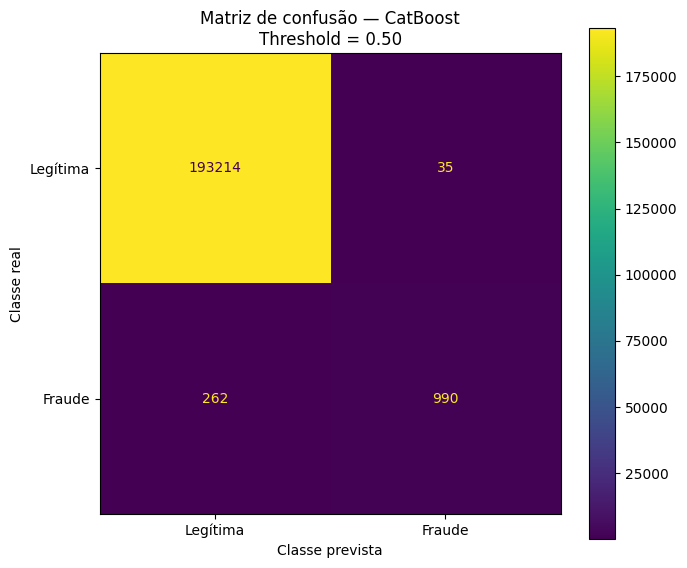

Figura salva em: /Users/lucassantos/Documents/ccard_fraud_ml/outputs/figures/catboost/01_matriz_confusao_catboost.png


In [72]:
fig, ax = plt.subplots(
    figsize=(7, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_true=y_real_cat,
    y_pred=y_previsto_cat,
    display_labels=[
        "Legítima",
        "Fraude"
    ],
    values_format="d",
    ax=ax
)

ax.set_title(
    "Matriz de confusão — CatBoost\n"
    f"Threshold = {threshold_cat:.2f}"
)

ax.set_xlabel("Classe prevista")
ax.set_ylabel("Classe real")

salvar_e_exibir_figura_cat(
    fig,
    "01_matriz_confusao_catboost"
)

In [73]:
taxa_falsos_positivos_cat, \
taxa_verdadeiros_positivos_cat, \
thresholds_roc_cat = roc_curve(
    y_real_cat,
    scores_validacao_catboost
)

roc_auc_cat = roc_auc_score(
    y_real_cat,
    scores_validacao_catboost
)

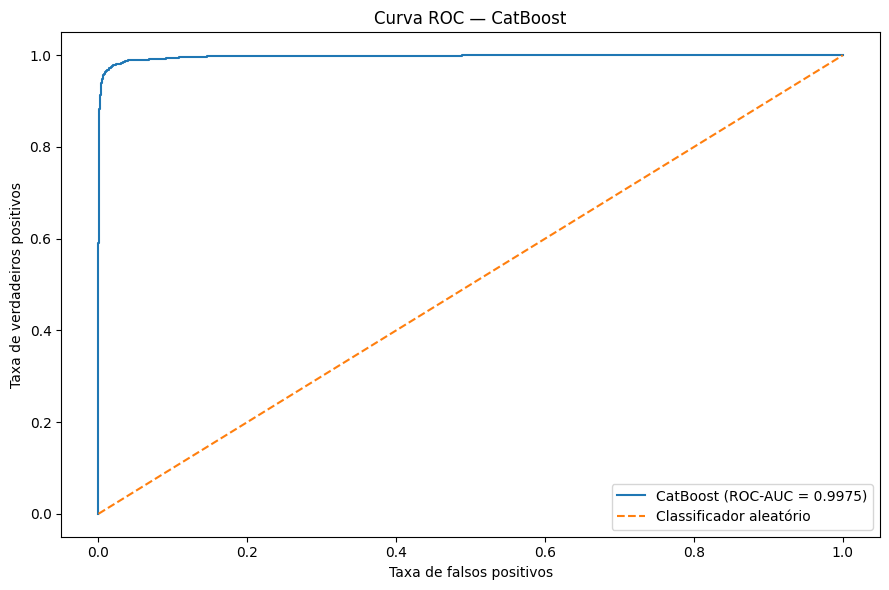

Figura salva em: /Users/lucassantos/Documents/ccard_fraud_ml/outputs/figures/catboost/02_curva_roc_catboost.png


In [74]:
fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.plot(
    taxa_falsos_positivos_cat,
    taxa_verdadeiros_positivos_cat,
    label=(
        "CatBoost "
        f"(ROC-AUC = {roc_auc_cat:.4f})"
    )
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classificador aleatório"
)

ax.set_title(
    "Curva ROC — CatBoost"
)

ax.set_xlabel(
    "Taxa de falsos positivos"
)

ax.set_ylabel(
    "Taxa de verdadeiros positivos"
)

ax.legend()

salvar_e_exibir_figura_cat(
    fig,
    "02_curva_roc_catboost"
)

In [75]:
precision_cat, recall_cat, thresholds_pr_cat = (
    precision_recall_curve(
        y_real_cat,
        scores_validacao_catboost
    )
)

average_precision_cat = (
    average_precision_score(
        y_real_cat,
        scores_validacao_catboost
    )
)

prevalencia_fraude = y_real_cat.mean()

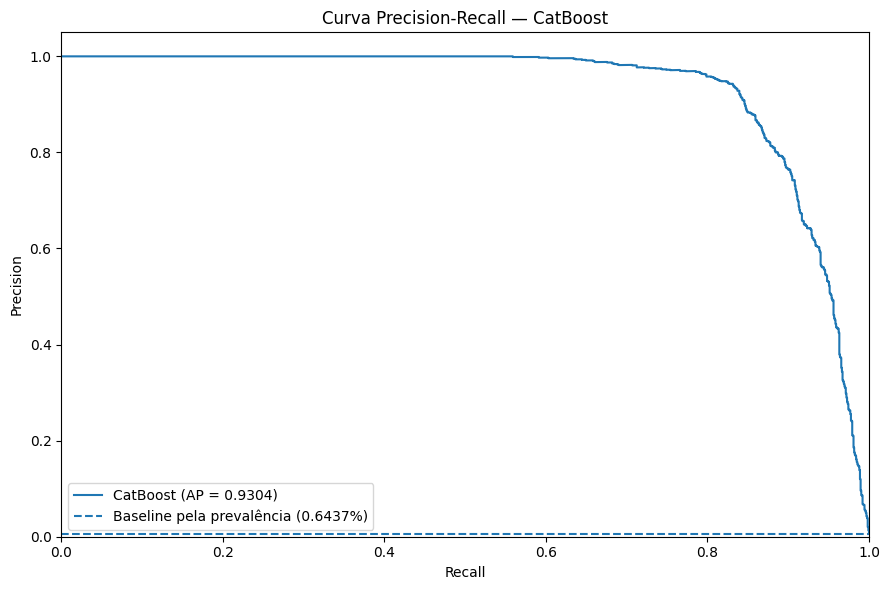

Figura salva em: /Users/lucassantos/Documents/ccard_fraud_ml/outputs/figures/catboost/03_curva_precision_recall_catboost.png


In [76]:
fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.plot(
    recall_cat,
    precision_cat,
    label=(
        "CatBoost "
        f"(AP = {average_precision_cat:.4f})"
    )
)

ax.axhline(
    y=prevalencia_fraude,
    linestyle="--",
    label=(
        "Baseline pela prevalência "
        f"({prevalencia_fraude:.4%})"
    )
)

ax.set_title(
    "Curva Precision-Recall — CatBoost"
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)

ax.legend()

salvar_e_exibir_figura_cat(
    fig,
    "03_curva_precision_recall_catboost"
)

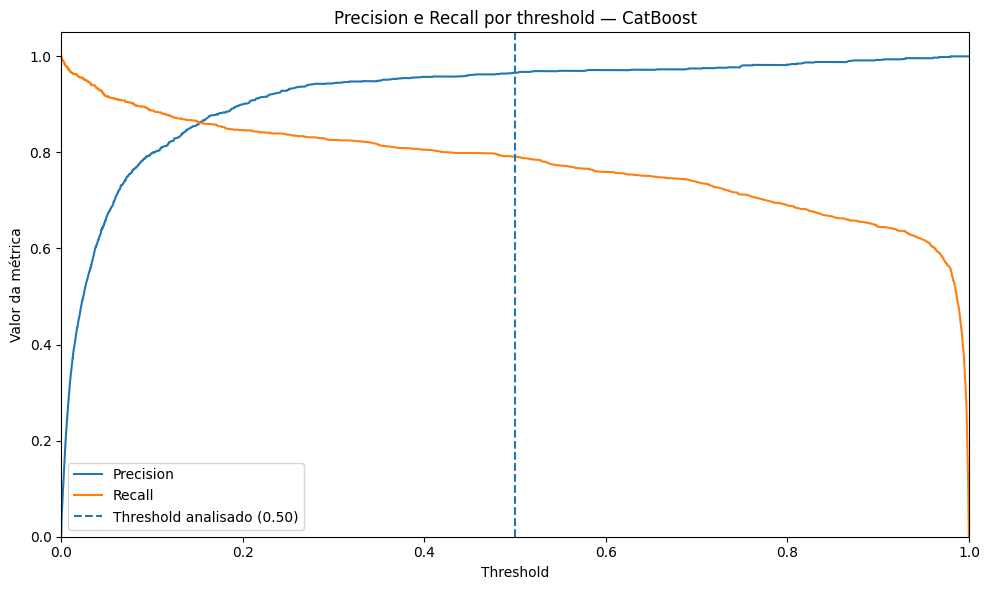

Figura salva em: /Users/lucassantos/Documents/ccard_fraud_ml/outputs/figures/catboost/04_precision_recall_por_threshold_catboost.png


In [77]:
fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    thresholds_pr_cat,
    precision_cat[:-1],
    label="Precision"
)

ax.plot(
    thresholds_pr_cat,
    recall_cat[:-1],
    label="Recall"
)

ax.axvline(
    x=threshold_cat,
    linestyle="--",
    label=(
        "Threshold analisado "
        f"({threshold_cat:.2f})"
    )
)

ax.set_title(
    "Precision e Recall por threshold — CatBoost"
)

ax.set_xlabel("Threshold")
ax.set_ylabel("Valor da métrica")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)

ax.legend()

salvar_e_exibir_figura_cat(
    fig,
    "04_precision_recall_por_threshold_catboost"
)

In [78]:
scores_legitimas_cat = (
    scores_validacao_catboost[
        y_real_cat == 0
    ]
)

scores_fraudes_cat = (
    scores_validacao_catboost[
        y_real_cat == 1
    ]
)


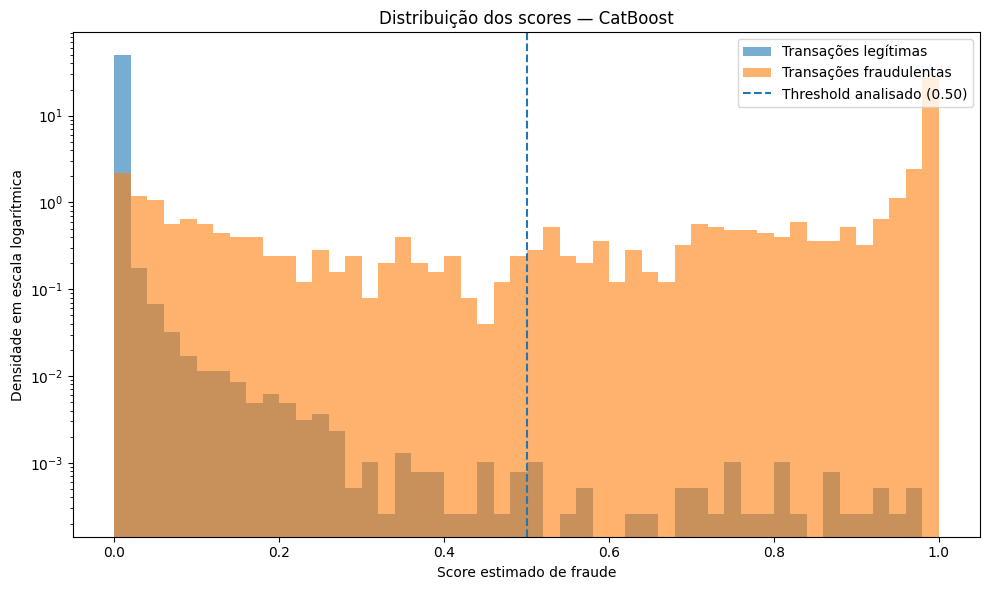

Figura salva em: /Users/lucassantos/Documents/ccard_fraud_ml/outputs/figures/catboost/05_distribuicao_scores_catboost.png


In [79]:
bins_scores = np.linspace(
    0,
    1,
    51
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.hist(
    scores_legitimas_cat,
    bins=bins_scores,
    density=True,
    alpha=0.6,
    label="Transações legítimas"
)

ax.hist(
    scores_fraudes_cat,
    bins=bins_scores,
    density=True,
    alpha=0.6,
    label="Transações fraudulentas"
)

ax.axvline(
    x=threshold_cat,
    linestyle="--",
    label=(
        "Threshold analisado "
        f"({threshold_cat:.2f})"
    )
)

ax.set_yscale("log")

ax.set_title(
    "Distribuição dos scores — CatBoost"
)

ax.set_xlabel(
    "Score estimado de fraude"
)

ax.set_ylabel(
    "Densidade em escala logarítmica"
)

ax.legend()

salvar_e_exibir_figura_cat(
    fig,
    "05_distribuicao_scores_catboost"
)

In [80]:
nomes_features_cat = X_treino_cat.columns.tolist()

In [81]:
importancias_cat = modelo_catboost.get_feature_importance(
    pool_treino,
    type="FeatureImportance"
)

In [82]:
tabela_importancias_cat = pd.DataFrame({
    "variavel": nomes_features_cat,
    "importancia": importancias_cat
})

In [83]:
tabela_importancias_cat = (
    tabela_importancias_cat
    .sort_values(
        "importancia",
        ascending=False
    )
    .reset_index(drop=True)
)

tabela_importancias_cat

,variavel,importancia
0,amt_log,33.377820
1,category,20.434172
2,idade,11.962480
3,hora_sin,11.274052
4,hora_cos,11.015607
5,city_pop_log,4.451477
6,gender,2.876683
7,distancia_km,1.496983
8,state,1.376388
9,dia_semana_sin,0.971027


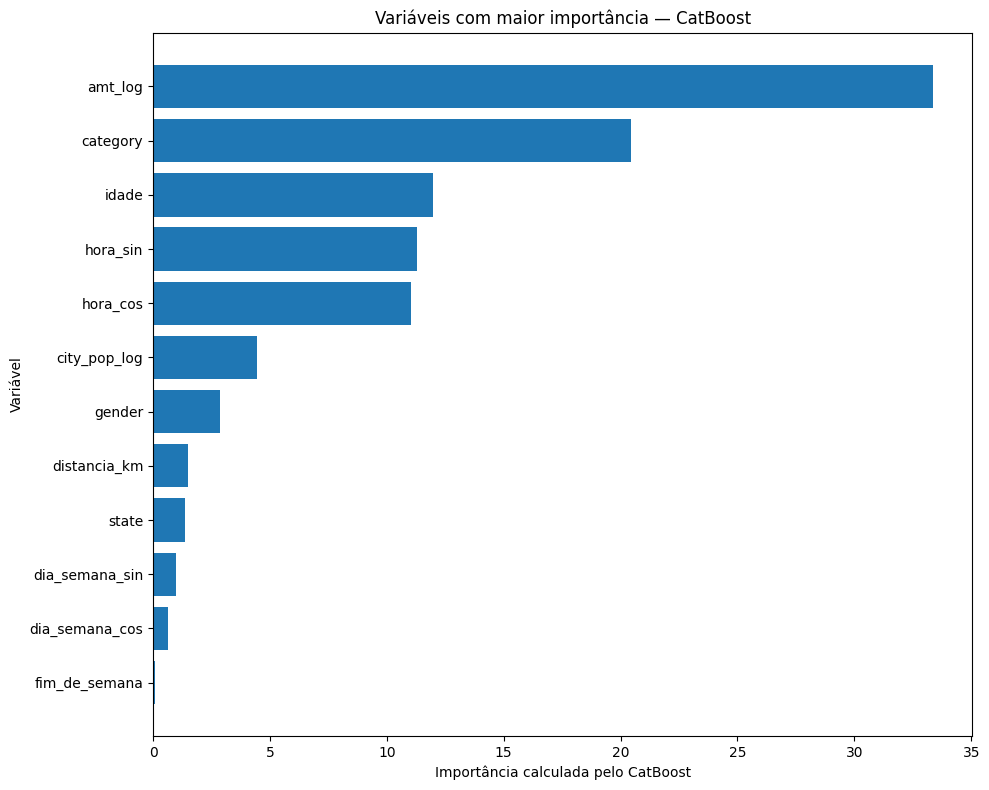

Figura salva em: /Users/lucassantos/Documents/ccard_fraud_ml/outputs/figures/catboost/06_importancia_variaveis_catboost.png


In [84]:
top_importancias_cat = (
    tabela_importancias_cat
    .head(20)
    .sort_values(
        "importancia",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

ax.barh(
    top_importancias_cat["variavel"],
    top_importancias_cat["importancia"]
)

ax.set_title(
    "Variáveis com maior importância — CatBoost"
)

ax.set_xlabel(
    "Importância calculada pelo CatBoost"
)

ax.set_ylabel("Variável")

salvar_e_exibir_figura_cat(
    fig,
    "06_importancia_variaveis_catboost"
)

In [85]:
historico_cat = modelo_catboost.get_evals_result()
historico_cat

{'learn': {'Logloss': [0.5328145879912788,
   0.42065706061760827,
   0.32932268289580874,
   0.25616371266645205,
   0.2047468733794574,
   0.15997606522911356,
   0.1287158484368635,
   0.09990206397446233,
   0.08058432545283485,
   0.06624421878745707,
   0.05429673789092508,
   0.04656991702549451,
   0.040287518046223963,
   0.03548902477343684,
   0.031691716968335316,
   0.028642362110899898,
   0.026534413584313174,
   0.02467513307566371,
   0.022744538312170225,
   0.021358528132175682,
   0.019532302920511578,
   0.018417560767604937,
   0.01726917606453841,
   0.016663225423483457,
   0.015572516111174956,
   0.015196364217172445,
   0.01439005382025282,
   0.01403155400982224,
   0.013442564890466363,
   0.013071614499550136,
   0.012768809817975532,
   0.012303443839693763,
   0.012101100561612187,
   0.011580042131465105,
   0.011380992756518988,
   0.01127125884990528,
   0.010905250352315987,
   0.010822388460509997,
   0.010515934943586458,
   0.010405863003526005,
 

In [86]:
historico_cat.keys()
# dict_keys(['learn', 'validation'])

dict_keys(['learn', 'validation'])

In [87]:
historico_cat["learn"].keys()
# dict_keys(['Logloss', 'PRAUC:type=Classic'])

dict_keys(['Logloss', 'PRAUC:type=Classic'])

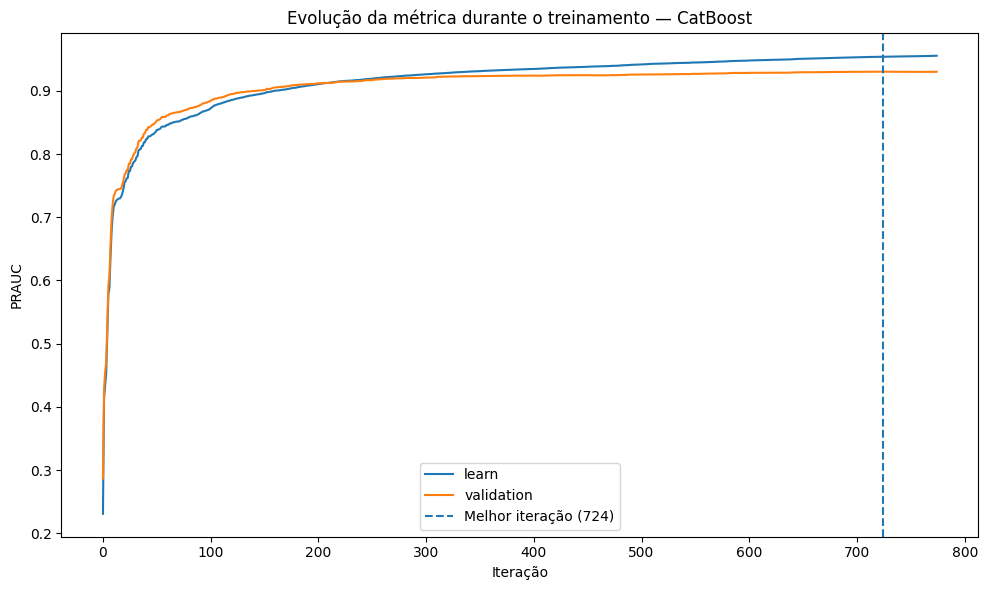

Figura salva em: /Users/lucassantos/Documents/ccard_fraud_ml/outputs/figures/catboost/07_evolucao_treinamento_catboost.png


In [88]:
fig, ax = plt.subplots(
    figsize=(10, 6)
)

for nome_conjunto, metricas in historico_cat.items():

    if "PRAUC:type=Classic" in metricas:
        nome_metrica = "PRAUC:type=Classic"
    else:
        nome_metrica = next(
            iter(metricas)
        )

    valores = metricas[nome_metrica]

    ax.plot(
        range(len(valores)),
        valores,
        label=nome_conjunto
    )

melhor_iteracao_cat = (
    modelo_catboost.get_best_iteration()
)

ax.axvline(
    x=melhor_iteracao_cat,
    linestyle="--",
    label=(
        "Melhor iteração "
        f"({melhor_iteracao_cat})"
    )
)

ax.set_title(
    "Evolução da métrica durante o treinamento — CatBoost"
)

ax.set_xlabel("Iteração")
ax.set_ylabel("PRAUC")

ax.legend()

salvar_e_exibir_figura_cat(
    fig,
    "07_evolucao_treinamento_catboost"
)

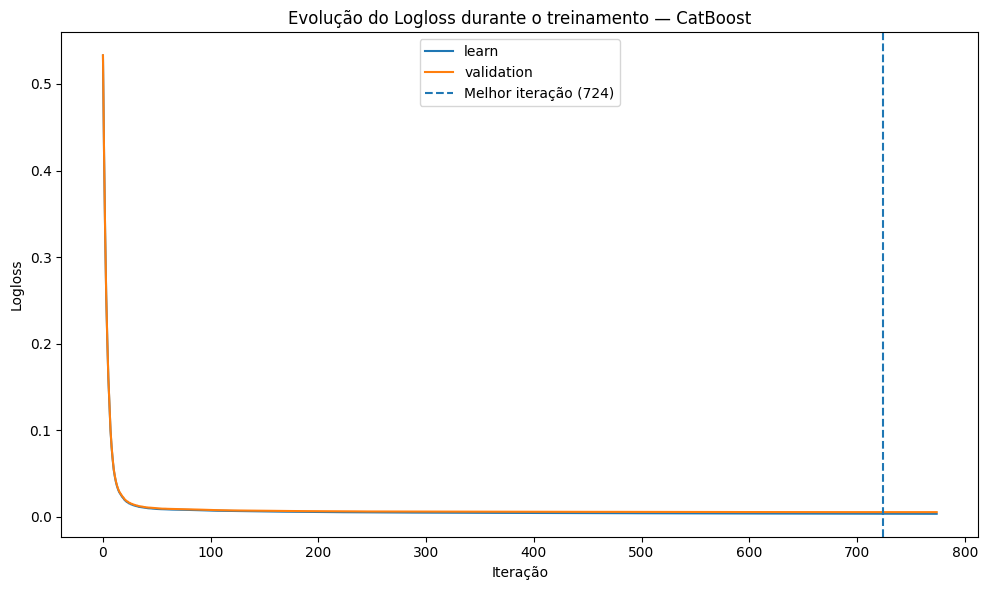

Figura salva em: /Users/lucassantos/Documents/ccard_fraud_ml/outputs/figures/catboost/08_evolucao_logloss_catboost.png


In [89]:
fig, ax = plt.subplots(
    figsize=(10, 6)
)

for nome_conjunto, metricas in historico_cat.items():
    if "Logloss" in metricas:
        valores = metricas["Logloss"]

        ax.plot(
            range(len(valores)),
            valores,
            label=nome_conjunto
        )

melhor_iteracao_cat = (
    modelo_catboost.get_best_iteration()
)

ax.axvline(
    x=melhor_iteracao_cat,
    linestyle="--",
    label=(
        "Melhor iteração "
        f"({melhor_iteracao_cat})"
    )
)

ax.set_title(
    "Evolução do Logloss durante o treinamento — CatBoost"
)

ax.set_xlabel("Iteração")
ax.set_ylabel("Logloss")

ax.legend()

salvar_e_exibir_figura_cat(
    fig,
    "08_evolucao_logloss_catboost"
)

In [90]:
dados_curva_roc_cat = pd.DataFrame({
    "taxa_falsos_positivos": (
        taxa_falsos_positivos_cat
    ),
    "taxa_verdadeiros_positivos": (
        taxa_verdadeiros_positivos_cat
    ),
    "threshold": thresholds_roc_cat
})

dados_curva_roc_cat.to_csv(
    PASTA_TABELAS_CAT
    / "curva_roc_catboost.csv",
    index=False,
    encoding="utf-8-sig"
)

In [91]:
dados_curva_pr_cat = pd.DataFrame({
    "precision": precision_cat[:-1],
    "recall": recall_cat[:-1],
    "threshold": thresholds_pr_cat
})

dados_curva_pr_cat.to_csv(
    PASTA_TABELAS_CAT
    / "curva_precision_recall_catboost.csv",
    index=False,
    encoding="utf-8-sig"
)

In [92]:
tabela_importancias_cat.to_csv(
    PASTA_TABELAS_CAT
    / "importancia_variaveis_catboost.csv",
    index=False,
    encoding="utf-8-sig"
)

In [93]:
dados_historico_cat = []

for nome_conjunto, metricas in historico_cat.items():
    for nome_metrica, valores in metricas.items():
        for iteracao, valor in enumerate(valores):
            dados_historico_cat.append({
                "conjunto": nome_conjunto,
                "metrica": nome_metrica,
                "iteracao": iteracao,
                "valor": valor
            })

tabela_historico_cat = pd.DataFrame(
    dados_historico_cat
)

tabela_historico_cat.to_csv(
    PASTA_TABELAS_CAT
    / "historico_treinamento_catboost.csv",
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
PASTA_MODELO = Path(
    "../models/catboost_v1"
)

PASTA_MODELO.mkdir(
    parents=True,
    exist_ok=True
)

In [ ]:
CAMINHO_MODELO = (
    PASTA_MODELO
    / "model.cbm"
)

modelo_catboost.save_model(
    str(CAMINHO_MODELO),
    format="cbm"
)

print(
    "Modelo salvo em:",
    CAMINHO_MODELO.resolve()
)